### First — The Big Picture
In single linear regression you had:

In [ ]:
y = theta0 + theta1 * X

### One input, two parameters.
Now with 3 features (Size, Bedrooms, Age):

In [ ]:
y = theta0 + theta1*Size + theta2*Bedrooms + theta3*Age
#Three inputs, four parameters. Same idea, bigger equation.

###Step 1 — Dataset

In [2]:
import numpy as np

# Each row = one house
# Columns = Size, Bedrooms, Age
X_raw = np.array([
    [1000, 2, 10],
    [1500, 3,  5],
    [2000, 4,  2],
    [1200, 2,  8],
    [1800, 3,  3],
    [2500, 5,  1],
    [ 900, 1, 15],
    [1600, 3,  6],
])

y = np.array([150000, 220000, 300000, 170000,
              260000, 380000, 120000, 230000])


#Why this shape? Each row is one sample. Each column is one feature. This is called a Feature Matrix.

###Step 2 — Feature Scaling
- Before doing anything, you need to scale your features.
- Why? Look at the ranges:
- Size     → 900  to 2500   (huge numbers)
- Bedrooms → 1    to 5      (small numbers)
- Age      → 1    to 15     (medium numbers)
- If you don't scale, gradient descent will take forever or behave badly — because Size dominates everything just by being a big number.

In [3]:
# Subtract mean, divide by std — brings everything to same scale
X_mean = X_raw.mean(axis=0)   # mean of each column
X_std  = X_raw.std(axis=0)    # std  of each column

X_scaled = (X_raw - X_mean) / X_std

#After scaling, all features will be roughly between -2 and +2. Now gradient descent treats them equally.

###Step 3 — Add Bias Column (Design Matrix)

In [4]:
# Add a column of 1s at the front
m = X_scaled.shape[0]                        # number of samples (8)
bias = np.ones((m, 1))                       # column of 1s
X = np.hstack([bias, X_scaled])              # stick it to the left

print(X.shape)   # (8, 4) → 8 samples, 4 columns

(8, 4)


###Why a column of 1s?
1. Because your equation is:
- y = theta0*1 + theta1*Size + theta2*Bedrooms + theta3*Age
- When you do matrix multiplication X @ theta, that column of 1s automatically handles theta0 (the intercept). No need to treat it separately like before.
- Your X now looks like:
- [ 1,  scaled_size,  scaled_bedrooms,  scaled_age ]
- [ 1,  ...                                        ]
- [ 1,  ...                                        ]

###Step 4 — Parameters (Theta Vector)

In [5]:
theta = np.zeros(4)   # [theta0, theta1, theta2, theta3]

#Before you had theta0=0, theta1=0 as separate variables.
#Now they live together in one vector.
#Cleaner, scalable to any number of features.

###Step 5 — Predict

In [6]:
def predict(X, theta):
    return X @ theta        # matrix multiplication


#  Why @ ?
#  X @ theta does this in one shot:
#  y_pred[0] = 1*theta0 + X[0,1]*theta1 + X[0,2]*theta2 + X[0,3]*theta3
#  y_pred[1] = 1*theta0 + X[1,1]*theta1 + X[1,2]*theta2 + X[1,3]*theta3
#  ...all 8 rows at once
#  It's the same as theta0 + theta1*X but for multiple features simultaneously.


###Step 6 — Cost Function

In [7]:
def mse(y_true, y_pred):
    n = len(y_true)
    return (1/n) * np.sum((y_true - y_pred) ** 2)

#Exactly the same as before.
#Cost doesn't care how many features you have — it just measures how wrong the predictions are.

###Step 7 — Gradient Descent

In [8]:
def fit(X, y, theta, lr=0.01, epochs=1000):
    n = len(y)
    costs = []

    for epoch in range(epochs):

        # Step 1: predict
        y_pred = predict(X, theta)

        # Step 2: cost
        cost = mse(y, y_pred)
        costs.append(cost)

        # Step 3: gradient (one line now — matrix math handles all thetas)
        gradient = (-2/n) * X.T @ (y - y_pred)

        # Step 4: update ALL thetas at once
        theta = theta - lr * gradient

    return theta, costs

###The key difference from before:
- Before (single)   ------------              Now (multiple)



---


- dm = (-2/n) * np.sum(X * error)--------gradient = (-2/n) * X.T @ error

---


- db = (-2/n) * np.sum(error)-------(included automatically via bias column)


---


- update 2 variables------------update 1 vector — all thetas at once

---

**Why X.T @ ?**

- X.T = transpose of X → flips rows and columns
- X.T @ error computes the gradient for all 4 thetas simultaneously
- Same math as before, just matrix form

###Step 8 — Train & Results

In [9]:
theta, costs = fit(X, y, theta, lr=0.01, epochs=1000)

print("Learned Parameters:")
print(f"  theta0 (intercept) : {theta[0]:.2f}")
print(f"  theta1 (size)      : {theta[1]:.2f}")
print(f"  theta2 (bedrooms)  : {theta[2]:.2f}")
print(f"  theta3 (age)       : {theta[3]:.2f}")

Learned Parameters:
  theta0 (intercept) : 228750.00
  theta1 (size)      : 49562.19
  theta2 (bedrooms)  : 29923.32
  theta3 (age)       : -63.38


###Step 9 — Predict New House

In [10]:
# New house: Size=1700, Bedrooms=3, Age=4
new_house = np.array([1700, 3, 4])

# Scale it using SAME mean and std from training data
new_house_scaled = (new_house - X_mean) / X_std

# Add bias (the 1)
new_house_final = np.hstack([1, new_house_scaled])

# Predict
price = predict(new_house_final, theta)
print(f"\nPredicted Price: ${price:,.0f}")


#Why use the same mean and std? Because your model learned on scaled data.
#If you feed it raw numbers now, it won't understand them.
#Always scale new data with training data's mean and std.


Predicted Price: $245,557


###Step 10 — Visualization

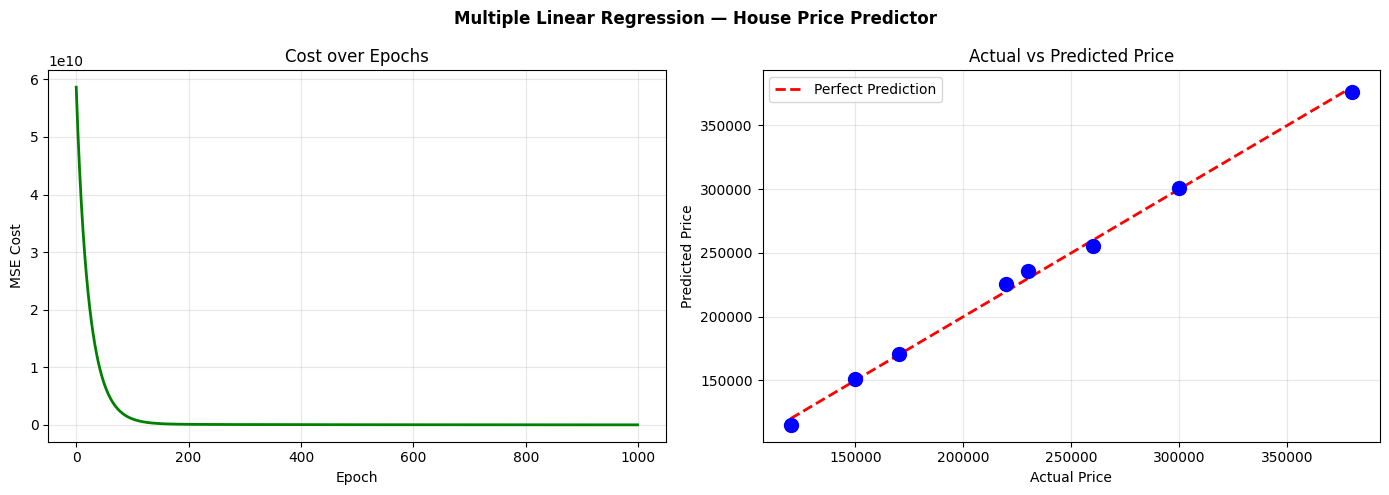

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Multiple Linear Regression — House Price Predictor", fontweight='bold')

# Plot 1: Cost going down
axes[0].plot(costs, color='green', linewidth=2)
axes[0].set_title("Cost over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Cost")
axes[0].grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted
y_pred_final = predict(X, theta)
axes[1].scatter(y, y_pred_final, color='blue', s=100, zorder=5)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()],
             color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
axes[1].set_title("Actual vs Predicted Price")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("house_price_prediction.png", dpi=150, bbox_inches='tight')
plt.show()

- Plot 2 explained: If your model is perfect, every dot sits on the red diagonal line. The closer dots are to that line, the better your model.

###The Complete Mental Map

In [ ]:
# Raw Data (X_raw)
#     │
#     ▼
#Feature Scaling         ← new (prevents big numbers dominating)
#     │
#     ▼
#Add Bias Column         ← new (handles theta0 automatically)
#     │
#     ▼
#theta = zeros(4)        ← now a vector, not separate variables
#     │
#     ▼
#Gradient Descent Loop (1000 times)
#     │
#     ├── y_pred   = X @ theta           ← matrix multiply (all features at once)
#     ├── cost     = mse(y, y_pred)      ← same as before
#     ├── gradient = (-2/n) * X.T @ err ← one line for all thetas
#     └── theta    = theta - lr*gradient ← update all at once
#     │
#     ▼
#Predict new house       ← scale first, add bias, then predict